# Week 1 과제 실행: YouTube 학습 동반자 ReAct 그래프

`create_agent` 없이 `StateGraph`로 직접 만든 ReAct 루프를 테스트합니다.

- `graph.py`: StateGraph + agent/tools 노드 + 조건부 엣지
- `tools.py`: 3개의 도메인 도구 (`fetch_video_transcript`, `summarize_video`, `generate_quiz`)
- `schema.py`: Pydantic 응답 스키마

In [ ]:
import os, sys
sys.path.insert(0, '.') # 로컬 파일 import 위해 추가

from dotenv import load_dotenv
load_dotenv('../../../.env', override=True)

True

## 1. 그래프 시각화

`agent ⇄ tools` 사이클 + `tools_condition`이 분기를 결정하는 ReAct 루프.

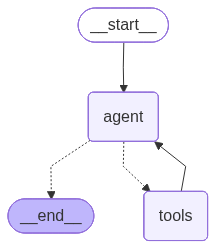

In [2]:
from IPython.display import Image, display
from graph import graph

display(Image(graph.get_graph().draw_mermaid_png()))

## 2. 실행 헬퍼

각 노드에서 어떤 메시지가 나오는지 trace를 함께 출력해 ReAct 루프의 동작을 가시화.

In [3]:
from langchain_core.messages import AIMessage, ToolMessage

def run(question: str):
    print('=' * 70)
    print(f'Q: {question}')
    print('=' * 70)
    final_state = None
    for event in graph.stream({'messages': [('human', question)]}, stream_mode='values'):
        msg = event['messages'][-1]
        if isinstance(msg, AIMessage):
            if msg.tool_calls:
                for call in msg.tool_calls:
                    args_preview = {k: (v[:80] + '...' if isinstance(v, str) and len(v) > 80 else v) for k, v in call['args'].items()}
                    print(f"\n[agent → tool_call] {call['name']}({args_preview})")
            elif msg.content:
                print(f'\n[agent → final answer]\n{msg.content}')
        elif isinstance(msg, ToolMessage):
            preview = msg.content if len(msg.content) < 500 else msg.content[:500] + '... (truncated)'
            print(f'\n[tools → observation · {msg.name}]\n{preview}')
        final_state = event
    return final_state

## 3. 테스트 1: 풀 학습 흐름 (도구 3개 모두 호출)

YouTube URL을 보내면 `fetch_video_transcript → summarize_video → generate_quiz`가 순차로 호출되고, agent 노드가 최종 응답을 생성한다.

In [4]:
TEST_VIDEO_URL = 'https://www.youtube.com/watch?v=gol5jv4wcfs&t=389s'
run(f'{TEST_VIDEO_URL} 이 영상 학습해줘')

Q: https://www.youtube.com/watch?v=gol5jv4wcfs&t=389s 이 영상 학습해줘

[agent → tool_call] fetch_video_transcript({'url': 'https://www.youtube.com/watch?v=gol5jv4wcfs&t=389s'})

[tools → observation · fetch_video_transcript]
{"video_id": "gol5jv4wcfs", "video_title": "깃헙 스타 10만개 받은 65줄짜리 CLAUDE.md (안드레 카파시)", "transcript": "클로점 MD 파일이 깃에서 10만 개 넘는 스타를 받았습니다. 프레임워크도 라이브러리도 아니고요. 그냥 클로점md 텍스트 파일 하나입니다. 그런데이 클로점md 파일 하나면 클로드 코드의 성능이 드라마틱하게 올라간다고 해서 전 세계 개발자들이 열광을 하고 있습니다. 자,이 레포지토리고요. 지금 10만2,000개 스타을 받았습니다. 그리고 클로점md 파일로 들어가 보면 단 65줄로 구성이 되어 있습니다. 이건 오픈 AI의 공동 창업자이자 테슬라의 AI 디렉터였던 안드레 카파시가 X에서 올린 글에서 시작된 건데요.이 글을 읽은 한 개발자가이 카파시의 메시지에서 핵심원칙네 가지를 딱 뽑아서 65줄짜리 클로점 MD 파일 하나로 정리를 했고이 레퍼가 단 며칠 만에 10만 개 넘는 스타를 받게 된 겁니다. 오늘이 영상... (truncated)

[agent → tool_call] summarize_video({'transcript': '클로점 MD 파일이 깃에서 10만 개 넘는 스타를 받았습니다. 프레임워크도 라이브러리도 아니고요. 그냥 클로점md 텍스트 파일 하나입니다. 그런...', 'video_title': '깃헙 스타 10만개 받은 65줄짜리 CLAUDE.md (안드레 카파시)'})

[tools → observation · summarize_video]
{"summary": "이 영상은 65줄짜리 C

{'messages': [HumanMessage(content='https://www.youtube.com/watch?v=gol5jv4wcfs&t=389s 이 영상 학습해줘', additional_kwargs={}, response_metadata={}, id='d7caf6b0-3f39-4377-9f54-38f91cfbe58d'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 37, 'prompt_tokens': 647, 'total_tokens': 684, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-DdfLKu7wC0yfIAXvNpxh9xcY1I1qc', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019e0daf-cae3-78a0-b052-b0101806b8c8-0', tool_calls=[{'name': 'fetch_video_transcript', 'args': {'url': 'https://www.youtube.com/watch?v=gol5jv4wcfs&t=389s'}, 'id': 'call_TcGHdoUbAHZkbXNZTtNvXweP', 'type': 'to

## 4. 테스트 2: 도구 호출 없는 일반 대화

`tools_condition`이 `tool_calls`가 없는 AIMessage를 보고 곧장 END로 라우팅.

In [5]:
run('안녕? 이 앱이 뭘 해주는지 간단히 설명해줄래?')

Q: 안녕? 이 앱이 뭘 해주는지 간단히 설명해줄래?

[agent → final answer]
{
  "kind": "chat",
  "message": "안녕하세요! 이 앱은 YouTube 영상 링크를 보내주시면, 영상을 학습용으로 정리해드리는 도구예요. \n\n주요 기능은:\n- 영상 자막/내용 추출\n- 핵심 요약 제공\n- 중요한 포인트 정리\n- 퀴즈로 복습하기\n\n원하시면 YouTube URL을 보내주세요. 바로 학습 모드로 도와드릴게요!",
  "video_title": null,
  "summary": null,
  "key_points": [],
  "quiz": []
}


{'messages': [HumanMessage(content='안녕? 이 앱이 뭘 해주는지 간단히 설명해줄래?', additional_kwargs={}, response_metadata={}, id='12378286-36f8-4c40-bb9c-363345a83838'),
  AIMessage(content='{\n  "kind": "chat",\n  "message": "안녕하세요! 이 앱은 YouTube 영상 링크를 보내주시면, 영상을 학습용으로 정리해드리는 도구예요. \\n\\n주요 기능은:\\n- 영상 자막/내용 추출\\n- 핵심 요약 제공\\n- 중요한 포인트 정리\\n- 퀴즈로 복습하기\\n\\n원하시면 YouTube URL을 보내주세요. 바로 학습 모드로 도와드릴게요!",\n  "video_title": null,\n  "summary": null,\n  "key_points": [],\n  "quiz": []\n}', additional_kwargs={}, response_metadata={}, id='4fb7e21c-ef0d-4e04-9a7c-ff8ecda4cddc', tool_calls=[], invalid_tool_calls=[])]}

## 5. 테스트 3: 잘못된 URL → 에러 후 우회

도구가 에러를 돌려줘도 `ToolNode(handle_tool_errors=True)` 기본값으로 ToolMessage가 만들어지고, agent가 이를 읽고 사용자에게 안내 응답으로 마무리한다.

In [6]:
run('https://example.com/not-a-youtube-url 이거 학습해줘')

Q: https://example.com/not-a-youtube-url 이거 학습해줘

[agent → tool_call] fetch_video_transcript({'url': 'https://example.com/not-a-youtube-url'})

[tools → observation · fetch_video_transcript]
{"error": "YouTube URL에서 video_id를 추출할 수 없습니다: https://example.com/not-a-youtube-url"}

[agent → final answer]
{
  "kind": "chat",
  "message": "이 URL은 YouTube 링크로 인식되지 않아서 학습을 진행할 수 없어요. YouTube 영상 URL을 보내주시면 바로 학습 모드로 정리해드릴게요!",
  "video_title": null,
  "summary": null,
  "key_points": [],
  "quiz": []
}


{'messages': [HumanMessage(content='https://example.com/not-a-youtube-url 이거 학습해줘', additional_kwargs={}, response_metadata={}, id='f49e1756-6544-43c7-b60f-8b71e7286dc0'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 637, 'total_tokens': 664, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-DdfO0FtXyDmDIVPqMT8dPLNeHb455', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019e0db2-56f6-72a0-8189-e0db5fa9b157-0', tool_calls=[{'name': 'fetch_video_transcript', 'args': {'url': 'https://example.com/not-a-youtube-url'}, 'id': 'call_qn24AGy2xe760JdzHri14G4Y', 'type': 'tool_call'}], invalid_tool_cal